# VisionGuard: Real-Time Driver Drowsiness Detection menggunakan Faster R-CNN

---

- Benedict Aurelius (2306209095)
- Deandro Najwan Ahmad Syahbanna (2306213174)
- Nelson Laurensius (2306161845)
- Wesley Frederick Oh (2306202763)

## BAGIAN 1: Environment Setup

In [ ]:
# 1.1 Instalasi Library
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split())

packages = [
    'torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118',
    'opencv-python-headless',
    'albumentations',
    'kaggle',
    'matplotlib seaborn',
    'tqdm',
    'Pillow',
    'pandas',
    'scikit-learn',
    'pycocotools',
    'torchmetrics',
    'ipywidgets',
    'mediapipe'
]

for pkg in packages:
    try:
        install(pkg)
        print(f'✅ {pkg.split()[0]} installed')
    except Exception as e:
        print(f'⚠️  {pkg.split()[0]}: {e}')

✅ torch installed
✅ opencv-python-headless installed
✅ albumentations installed
✅ kaggle installed
✅ matplotlib installed
✅ tqdm installed
✅ Pillow installed
✅ pandas installed
✅ scikit-learn installed
✅ pycocotools installed
✅ torchmetrics installed
✅ ipywidgets installed
✅ mediapipe installed


In [ ]:
# 1.2 Import Library
import os, sys, json, time, random, shutil, warnings, glob, re, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import torch.quantization
from collections import defaultdict
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter, defaultdict
from copy import deepcopy
from google.colab import drive

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F

# OpenCV
import cv2

# Augmentasi
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
from torchmetrics.detection.mean_ap import MeanAveragePrecision

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

# 1.3 Konfigurasi Device
drive.mount('/content/drive')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')

if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# 1.4 Hyperparameter & Path
CFG = {
    # Path
    'DATA_ROOT'     : './nthu_ddd',
    'ANNO_DIR'      : './annotations',
    'IMG_DIR'       : './src',
    'CHECKPOINT_DIR': '/content/drive/MyDrive/checkpoints',

    # Dataset
    'IMG_SIZE'      : 640,
    'TRAIN_RATIO'   : 0.75,
    'VAL_RATIO'     : 0.15,
    'TEST_RATIO'    : 0.10,

    # Training
    'BATCH_SIZE'    : 4,
    'NUM_EPOCHS'    : 20,
    'LR'            : 0.005,
    'MOMENTUM'      : 0.9,
    'WEIGHT_DECAY'  : 5e-4,
    'LR_STEP_SIZE'  : 7,
    'LR_GAMMA'      : 0.1,
    'NUM_WORKERS'   : 0,

    # Model
    'SCORE_THRESH'  : 0.5,
    'NMS_THRESH'    : 0.4,
    'SEED'          : 42,

    # Kelas (0 = background, 1-4 = objek)
    'CLASSES': [
        '__background__',
        'notdrowsy',
        'sleepyCombination',
        'slowBlinkWithNodding',
        'yawning'
    ]
}
CFG['NUM_CLASSES'] = len(CFG['CLASSES'])

# Warna per kelas untuk visualisasi
CLASS_COLORS = {
    'notdrowsy'            : (0,   200,  0),
    'sleepyCombination'    : (255, 200,  0),
    'slowBlinkWithNodding' : (255, 165,  0),
    'yawning'              : (220,  20, 60)
}

# Reproducibility
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG['SEED'])

# Buat direktori
for d in [CFG['ANNO_DIR'], CFG['CHECKPOINT_DIR'], CFG['IMG_DIR']]:
    os.makedirs(d, exist_ok=True)

print('\n📁 Konfigurasi siap!')
print(f'   Classes  : {CFG["CLASSES"][1:]}')
print(f'   Num Class: {CFG["NUM_CLASSES"]} (+ background)')

Mounted at /content/drive
🖥️  Device: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB
✅ Metadata konsisten
Jumlah class total : 5
✅ Class mapping valid

📁 Konfigurasi siap!
   Classes  : ['notdrowsy', 'sleepyCombination', 'slowBlinkWithNodding', 'yawning']
   Num Class: 5 (+ background)


## BAGIAN 2: Data Collection (Download Dataset Kaggle)

In [ ]:
# 2.1 Download Dataset
DATASET_SLUG = 'samymesbah/nthu-dataset-ddd-multi-class'
DOWNLOAD_DIR = './Multi class/train'

if not os.path.exists(DOWNLOAD_DIR) or len(os.listdir(DOWNLOAD_DIR)) == 0:
    print('📥 Mengunduh dataset...')
    os.makedirs('./', exist_ok=True)
    result = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', DATASET_SLUG,
         '--path', './', '--unzip'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('✅ Download berhasil!')
    else:
        print(f'❌ Error: {result.stderr}')
else:
    print('✅ Dataset sudah ada, melewati download.')

# 2.2 Jelajahi Struktur Dataset
print('\n📂 Struktur Dataset:')
for root, dirs, files in os.walk(DOWNLOAD_DIR):
    depth = root.replace(DOWNLOAD_DIR, '').count(os.sep)
    indent = '   ' * depth
    folder_name = os.path.basename(root)
    n_files = len(files)
    if depth <= 3:
        print(f'{indent}📁 {folder_name}/  [{n_files} files]')
    if depth == 3 and files:
        sample = files[:2]
        for s in sample:
            print(f'{indent}   └─ {s}')

📥 Mengunduh dataset...
✅ Download berhasil!

📂 Struktur Dataset:
📁 train/  [0 files]
   📁 drowsy/  [0 files]
      📁 slowBlinkWithNodding/  [9412 files]
      📁 sleepyCombination/  [17756 files]
      📁 yawning/  [8862 files]
   📁 notdrowsy/  [30491 files]


In [ ]:
# 2.3 Organisasi & Pemetaan Kelas Dataset

# Mapping nama folder → label kelas
FOLDER_TO_CLASS = {
    'notdrowsy'            : 'notdrowsy',
    'sleepyCombination'    : 'sleepyCombination',
    'slowBlinkWithNodding' : 'slowBlinkWithNodding',
    'yawning'              : 'yawning'
}

# Scan semua gambar & assign label
IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp'}
records = []

for root, dirs, files in os.walk(DOWNLOAD_DIR):
    folder_name = os.path.basename(root)
    label = FOLDER_TO_CLASS.get(folder_name, None)
    if label is None:
        # coba case-insensitive
        for k, v in FOLDER_TO_CLASS.items():
            if k.lower() == folder_name.lower():
                label = v
                break
    if label is None:
        continue
    for fname in files:
        if Path(fname).suffix.lower() in IMG_EXT:
            records.append({
                'image_path': os.path.join(root, fname),
                'label': label,
                'folder': folder_name
            })

df = pd.DataFrame(records)
print(f'📊 Total gambar ditemukan : {len(df)}')
print(f'   Distribusi kelas:')
print(df['label'].value_counts().to_string())

📊 Total gambar ditemukan : 66521
   Distribusi kelas:
label
notdrowsy               30491
sleepyCombination       17756
slowBlinkWithNodding     9412
yawning                  8862


## BAGIAN 3: Data Understanding: Eksplorasi Data

In [ ]:
# 3.1 Distribusi Kelas (Bar Chart)
class_counts = df['label'].value_counts()
colors_bar   = ['#2ecc71','#f39c12','#f1c40f','#e74c3c','#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=colors_bar, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribusi Kelas Dataset', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 5,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./src/class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n📊 Statistik:')
print(f'   Total gambar     : {len(df):,}')
print(f'   Jumlah kelas     : {df["label"].nunique()}')
print(f'   Kelas terbanyak  : {class_counts.idxmax()} ({class_counts.max():,})')
print(f'   Kelas tersedikit : {class_counts.idxmin()} ({class_counts.min():,})')

In [ ]:
# 3.2 Visualisasi Sample Gambar per Kelas
fig, axes = plt.subplots(2, len(CFG['CLASSES'])-1, figsize=(18, 7))
classes = CFG['CLASSES'][1:]  # skip background

for col, cls in enumerate(classes):
    subset = df[df['label'] == cls]['image_path'].values
    for row in range(2):
        ax = axes[row][col]
        if len(subset) > row:
            try:
                img = Image.open(subset[row]).convert('RGB')
                img = img.resize((200, 160))
                ax.imshow(img)
                color = colors_bar[col]
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(3)
            except Exception:
                ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(cls.replace('_','\n'), fontsize=10, fontweight='bold', pad=6)

plt.suptitle('Sample Gambar per Kelas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./src/sample_images.png', bbox_inches='tight', dpi=120)
plt.show()

In [ ]:
# 3.3 Analisis Properti Gambar (Resolusi, Brightness)
print('📐 Menganalisis properti gambar (sample 300)...')
SAMPLE_N = min(300, len(df))
sample_df = df.sample(SAMPLE_N, random_state=CFG['SEED'])

widths, heights, brights = [], [], []
for path in tqdm(sample_df['image_path'], desc='Analisis'):
    try:
        img = np.array(Image.open(path).convert('RGB'))
        widths.append(img.shape[1])
        heights.append(img.shape[0])
        brights.append(img.mean())
    except Exception:
        pass

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=30, color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribusi Lebar Gambar', fontweight='bold')
axes[0].set_xlabel('Lebar (px)')
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'Median: {np.median(widths):.0f}')
axes[0].legend()

axes[1].hist(heights, bins=30, color='#e67e22', edgecolor='black', linewidth=0.5)
axes[1].set_title('Distribusi Tinggi Gambar', fontweight='bold')
axes[1].set_xlabel('Tinggi (px)')
axes[1].axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.0f}')
axes[1].legend()

axes[2].hist(brights, bins=30, color='#1abc9c', edgecolor='black', linewidth=0.5)
axes[2].set_title('Distribusi Kecerahan Gambar', fontweight='bold')
axes[2].set_xlabel('Nilai Rata-rata Piksel')
axes[2].axvline(np.median(brights), color='red', linestyle='--', label=f'Median: {np.median(brights):.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('./src/image_properties.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n📐 Statistik Gambar:')
print(f'   Resolusi umum : {int(np.median(widths))}×{int(np.median(heights))} px')
print(f'   Kecerahan rata: {np.mean(brights):.1f} / 255')

## BAGIAN 4: Data Preparation

In [ ]:
# 4.1 Generate Bounding Box dengan HSV Masking (Mendeteksi Kotak Hijau)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CFG['CLASSES'])}

# Tentukan path file anotasi di awal
anno_path = os.path.join(CFG['ANNO_DIR'], 'annotations.csv')

def detect_face_bbox(image_path):
    """
    Deteksi wajah dengan mendeteksi letak kotak hijau dan mengembalikan [x1,y1,x2,y2].
    Jika tidak ditemukan, return bbox seluruh gambar.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None, None, None
    h, w = img.shape[:2]

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask_green = cv2.inRange(hsv, np.array([40, 150, 150]), np.array([80, 255, 255]))
    mask_blue  = cv2.inRange(hsv, np.array([100, 150, 150]), np.array([140, 255, 255]))
    mask_red1  = cv2.inRange(hsv, np.array([0, 150, 150]), np.array([10, 255, 255]))
    mask_red2  = cv2.inRange(hsv, np.array([160, 150, 150]), np.array([179, 255, 255]))
    all_colors_mask = mask_green | mask_blue | mask_red1 | mask_red2

    y_indices, x_indices = np.where(all_colors_mask > 0)
    if len(x_indices) > 0 and len(y_indices) > 0:
        x1, x2 = int(np.min(x_indices)), int(np.max(x_indices))
        y1, y2 = int(np.min(y_indices)), int(np.max(y_indices))
        return [x1, y1, x2, y2], w, h

    # Fallback: bbox seluruh gambar
    return [0, 0, w-1, h-1], w, h

# Cek apakah file anotasi sudah ada
if os.path.exists(anno_path):
    print(f'✅ File anotasi ditemukan di {anno_path}')
    print('🔄 Memuat data dari cache (melewati proses deteksi wajah)...')

    # Baca CSV
    anno_df = pd.read_csv(anno_path)

    # Konversi kolom 'bbox' dari tipe string kembali ke bentuk list [x1, y1, x2, y2]
    if 'bbox' in anno_df.columns and isinstance(anno_df['bbox'].iloc[0], str):
        anno_df['bbox'] = anno_df['bbox'].apply(ast.literal_eval)

    print(f'✅ Berhasil memuat {len(anno_df):,} anotasi gambar.')

else:
    # Jika file belum ada, jalankan proses deteksi
    print('🔍 File anotasi belum ada. Memulai deteksi wajah untuk generate bounding box...')
    print(f'   Total gambar: {len(df):,}')
    print('   (Proses ini memakan sedikit waktu karena mendeteksi jutaan piksel)')

    annotations = []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Detecting faces via Green Box'):
        bbox, w, h = detect_face_bbox(row['image_path'])
        if bbox is None:
            skipped += 1
            continue
        annotations.append({
            'image_path': row['image_path'],
            'label'     : row['label'],
            'label_idx' : CLASS_TO_IDX[row['label']],
            'bbox'      : bbox,   # [x1, y1, x2, y2]
            'img_w'     : w,
            'img_h'     : h
        })

    anno_df = pd.DataFrame(annotations)
    print(f'\n✅ Anotasi selesai!')
    print(f'   Berhasil : {len(anno_df):,} gambar')
    print(f'   Dilewati : {skipped} gambar (tidak bisa dibaca)')

    # Pastikan folder tujuan tersedia sebelum menyimpan
    os.makedirs(CFG['ANNO_DIR'], exist_ok=True)

    # Simpan ke disk
    anno_df.to_csv(anno_path, index=False)
    print(f'   💾 Disimpan ke {anno_path}')

✅ File anotasi ditemukan di ./annotations/annotations.csv
🔄 Memuat data dari cache (melewati proses deteksi wajah)...
✅ Berhasil memuat 66,521 anotasi gambar.


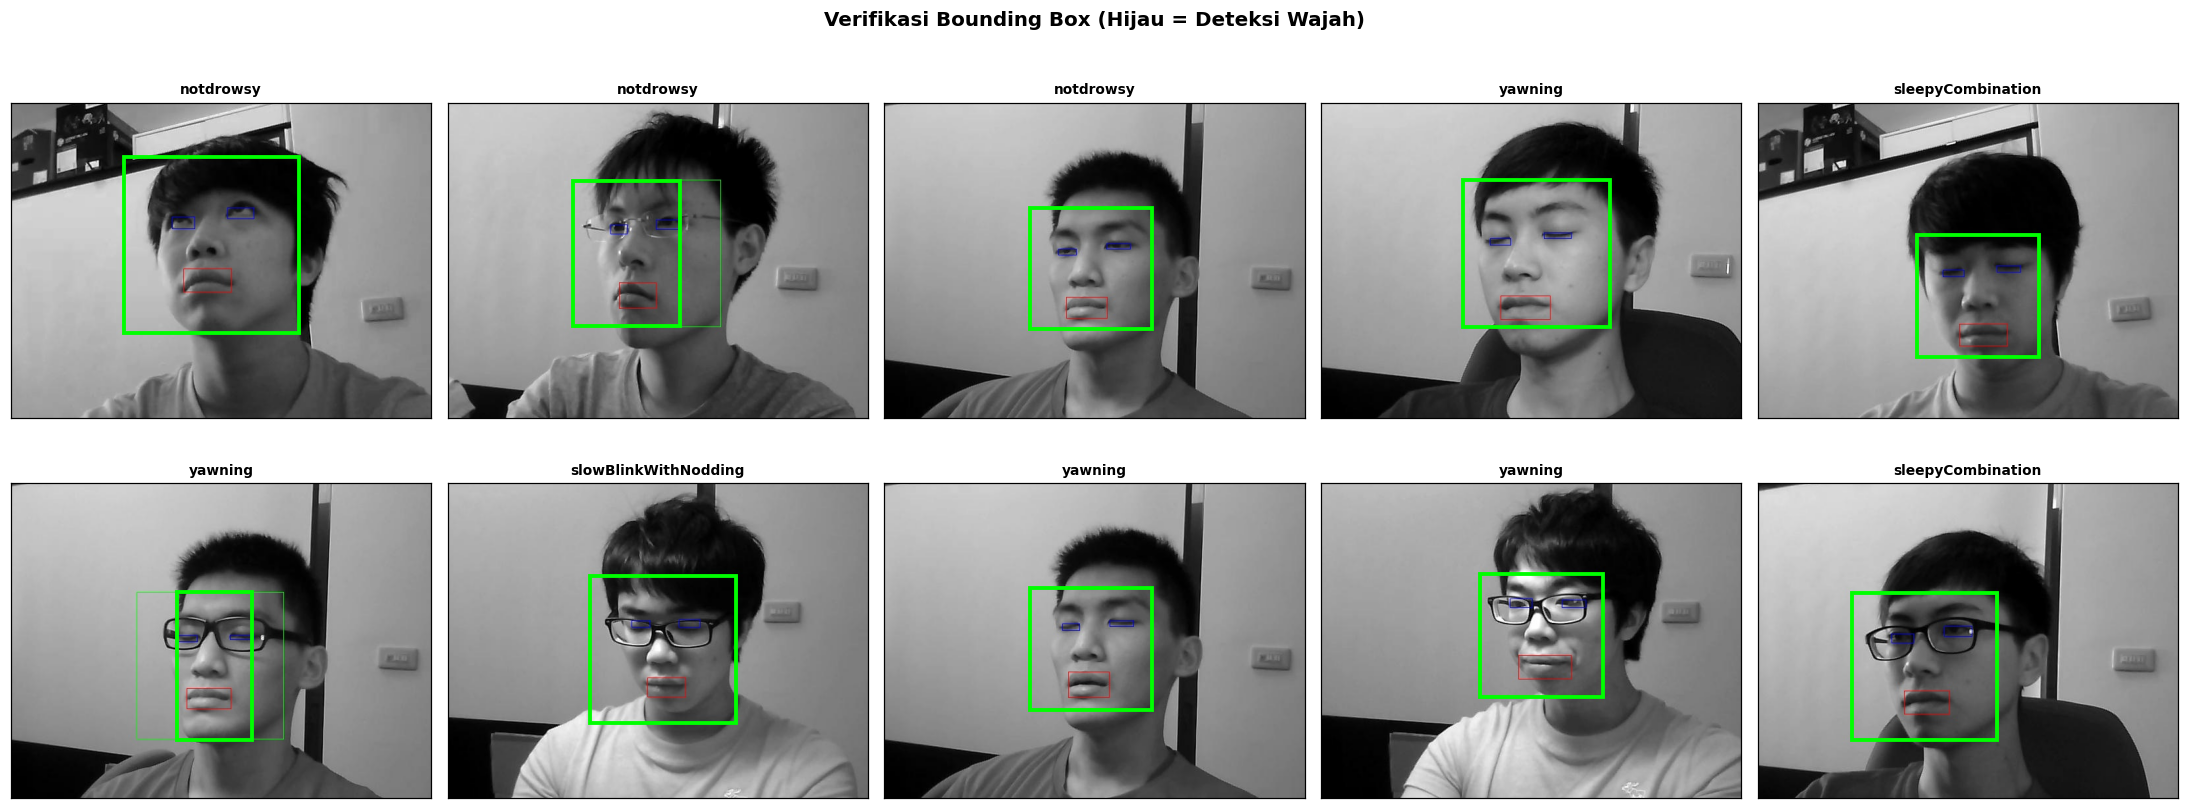

In [ ]:
# 4.2 Verifikasi Bounding Box
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sample_rows = anno_df.sample(10, random_state=CFG['SEED']).reset_index(drop=True)

for i, row in sample_rows.iterrows():
    ax = axes[i // 5][i % 5]
    try:
        img = np.array(Image.open(row['image_path']).convert('RGB'))
        ax.imshow(img)
        x1, y1, x2, y2 = row['bbox']
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.set_title(row['label'].replace('_','\n'), fontsize=9, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, str(e), ha='center', va='center', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Verifikasi Bounding Box (Hijau = Deteksi Wajah)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./src/bbox_verification.png', bbox_inches='tight', dpi=120)
plt.show()

✂️  Split Dataset:
   Train : 49,890 gambar (75.0%)
   Val   : 9,978 gambar (15.0%)
   Test  : 6,653 gambar (10.0%)


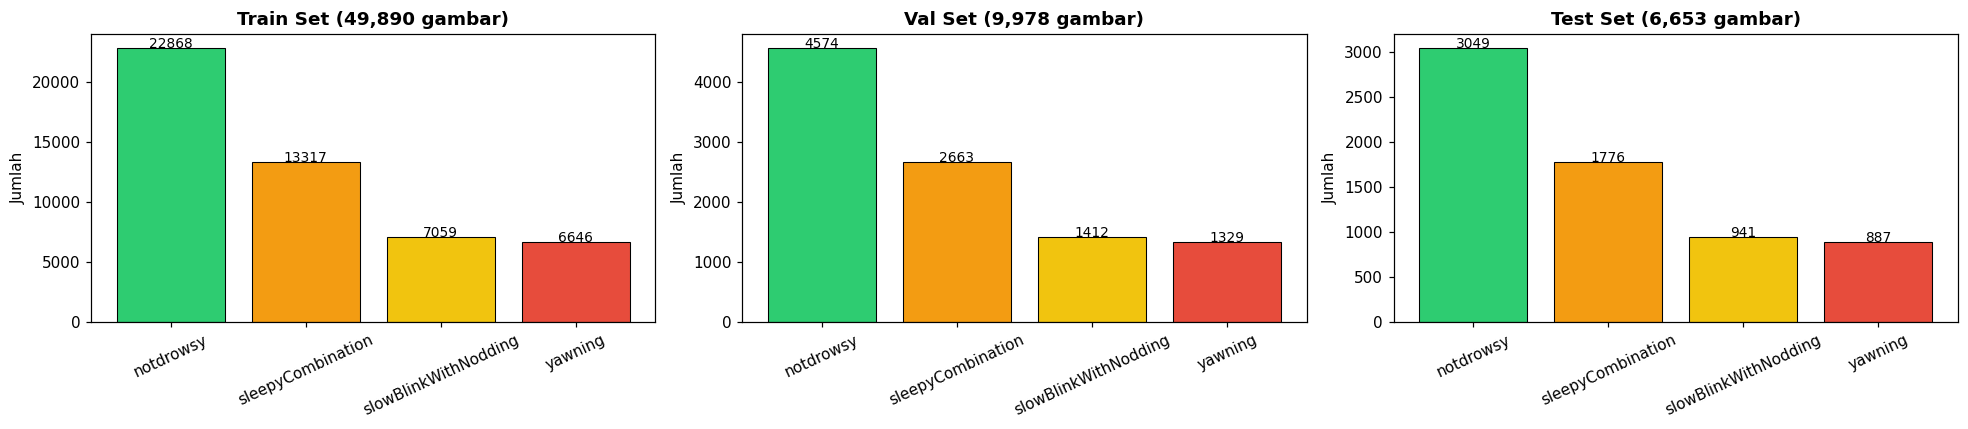

In [ ]:
# 4.3 Stratified Train / Val / Test Split
from sklearn.model_selection import train_test_split

# Split 75% train, 15% val, 10% test (stratified per kelas)
train_df, temp_df = train_test_split(
    anno_df, test_size=(CFG['VAL_RATIO'] + CFG['TEST_RATIO']),
    stratify=anno_df['label'], random_state=CFG['SEED']
)
val_ratio_adj = CFG['VAL_RATIO'] / (CFG['VAL_RATIO'] + CFG['TEST_RATIO'])
val_df, test_df = train_test_split(
    temp_df, test_size=(1 - val_ratio_adj),
    stratify=temp_df['label'], random_state=CFG['SEED']
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('✂️  Split Dataset:')
print(f'   Train : {len(train_df):,} gambar ({len(train_df)/len(anno_df)*100:.1f}%)')
print(f'   Val   : {len(val_df):,} gambar ({len(val_df)/len(anno_df)*100:.1f}%)')
print(f'   Test  : {len(test_df):,} gambar ({len(test_df)/len(anno_df)*100:.1f}%)')

# Visualisasi distribusi per split
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)
for ax, (name, data) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    vc = data['label'].value_counts()
    ax.bar(vc.index, vc.values, color=colors_bar[:len(vc)], edgecolor='black', linewidth=0.7)
    ax.set_title(f'{name} Set ({len(data):,} gambar)', fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=25)
    for p in ax.patches:
        ax.text(p.get_x()+p.get_width()/2, p.get_height()+2,
                str(int(p.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('./src/split_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

In [ ]:
# 4.4 Custom Dataset Class untuk Faster R-CNN
class DrowsinessDataset(Dataset):
    """
    Dataset untuk Faster R-CNN.
    Output: (image_tensor, target_dict)
    target_dict = {
        'boxes'  : FloatTensor[N,4],   # x1,y1,x2,y2
        'labels' : Int64Tensor[N],     # kelas idx (1-based, 0=bg)
        'image_id': Int64Tensor[1]
    }
    """
    def __init__(self, df, transform=None, img_size=640):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.img_size  = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]

        img_bgr = cv2.imread(row['image_path'])

        # 1. HAPUS KOTAK WARNA (Inpainting) AGAR MODEL TIDAK CURANG
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        mask_green = cv2.inRange(hsv, np.array([40, 150, 150]), np.array([80, 255, 255]))
        mask_blue  = cv2.inRange(hsv, np.array([100, 150, 150]), np.array([140, 255, 255]))
        mask_red1  = cv2.inRange(hsv, np.array([0, 150, 150]), np.array([10, 255, 255]))
        mask_red2  = cv2.inRange(hsv, np.array([160, 150, 150]), np.array([179, 255, 255]))

        all_colors_mask = mask_green | mask_blue | mask_red1 | mask_red2
        kernel = np.ones((3,3), np.uint8)
        all_colors_mask = cv2.dilate(all_colors_mask, kernel, iterations=1)

        img_cleaned = cv2.inpaint(img_bgr, all_colors_mask, 3, cv2.INPAINT_TELEA)

        # Convert ke RGB (format standar Albumentations & PyTorch)
        img = cv2.cvtColor(img_cleaned, cv2.COLOR_BGR2RGB)

        # Parse bbox dari dataframe
        if isinstance(row['bbox'], str):
            bbox = ast.literal_eval(row['bbox'])
        else:
            bbox = row['bbox']
        x1, y1, x2, y2 = bbox
        label_idx = int(row['label_idx'])

        # Albumentations augmentation
        if self.transform:
            transformed = self.transform(
                image=img,
                bboxes=[[x1, y1, x2, y2]],
                labels=[label_idx]
            )
            img = transformed['image']          # sudah tensor HWC→CHW float/uint8
            bboxes = transformed['bboxes']
            labels = transformed['labels']
        else:
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0
            bboxes = [[x1, y1, x2, y2]]
            labels = [label_idx]

        if len(bboxes) == 0:
            # Augmentasi menghilangkan bbox → kembalikan seluruh gambar
            h, w = img.shape[-2], img.shape[-1]
            bboxes = [[0, 0, w, h]]
            labels = [label_idx]

        target = {
            'boxes'   : torch.tensor(bboxes, dtype=torch.float32),
            'labels'  : torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx], dtype=torch.int64)
        }
        return img, target


print('✅ DrowsinessDataset class siap')


✅ DrowsinessDataset class siap


In [ ]:
# 4.5 Augmentasi Data
IMG_SIZE = CFG['IMG_SIZE']

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.3),
    A.GaussianBlur(blur_limit=(3,7), p=0.3),
    A.RandomGamma(gamma_limit=(80,120), p=0.3),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.3),  # Penting untuk kondisi siang/malam
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'],
                             min_visibility=0.3))

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'],
                             min_visibility=0.3))

# 4.6 Buat DataLoader
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = DrowsinessDataset(train_df, transform=train_transform, img_size=IMG_SIZE)
val_dataset   = DrowsinessDataset(val_df,   transform=val_transform,   img_size=IMG_SIZE)
test_dataset  = DrowsinessDataset(test_df,  transform=val_transform,   img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=CFG['BATCH_SIZE'],
                          shuffle=True,  num_workers=CFG['NUM_WORKERS'],
                          collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=CFG['NUM_WORKERS'],
                          collate_fn=collate_fn, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,
                          shuffle=False, num_workers=0,
                          collate_fn=collate_fn)

print('✅ DataLoader siap:')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')

# Verifikasi satu batch
imgs, targets = next(iter(train_loader))
print(f'\n🔍 Bentuk satu batch:')
print(f'   Gambar[0] shape: {imgs[0].shape}')
print(f'   BBox[0]        : {targets[0]["boxes"]}')
print(f'   Label[0]       : {targets[0]["labels"]} → {[CFG["CLASSES"][l] for l in targets[0]["labels"].tolist()]}')

✅ DataLoader siap:
   Train batches : 12473
   Val batches   : 2495
   Test batches  : 6653

🔍 Bentuk satu batch:
   Gambar[0] shape: torch.Size([3, 640, 640])
   BBox[0]        : tensor([[198.9381, 123.4224, 432.7845, 430.1740]])
   Label[0]       : tensor([2]) → ['sleepyCombination']


## BAGIAN 5: Training Model: Faster R-CNN

Menggunakan **Faster R-CNN dengan ResNet-50 + FPN** yang telah di-pretrain pada COCO.
Kita hanya mengganti layer classifier terakhir sesuai jumlah kelas kita.

In [ ]:
# 5.1 Bangun Model Faster R-CNN
def build_faster_rcnn(num_classes, score_thresh=0.5):
    """
    Load Faster R-CNN pretrained COCO, ganti head classifier.
    num_classes termasuk background (jadi 6 untuk 5 kelas).
    """
    # Load pretrained weights COCO
    model = fasterrcnn_resnet50_fpn(
        weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )

    # Ganti kepala klasifikasi & regresi box
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Sesuaikan threshold
    model.roi_heads.score_thresh   = score_thresh
    model.roi_heads.nms_thresh     = CFG['NMS_THRESH']
    model.roi_heads.detections_per_img = 10

    return model

model = build_faster_rcnn(CFG['NUM_CLASSES'], CFG['SCORE_THRESH'])
model = model.to(DEVICE)

# Hitung parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'🏗️  Model: Faster R-CNN (ResNet-50 + FPN)')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')
print(f'   Num classes     : {CFG["NUM_CLASSES"]} (bg + {CFG["NUM_CLASSES"]-1} kelas)')

# 5.2 Optimizer & Scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(
    params, lr=CFG['LR'],
    momentum=CFG['MOMENTUM'],
    weight_decay=CFG['WEIGHT_DECAY']
)
lr_scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=CFG['LR_STEP_SIZE'], gamma=CFG['LR_GAMMA']
)

print(f'\n⚙️  Optimizer: SGD (lr={CFG["LR"]}, momentum={CFG["MOMENTUM"]})')
print(f'   Scheduler: StepLR (step={CFG["LR_STEP_SIZE"]}, gamma={CFG["LR_GAMMA"]})')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 198MB/s]


🏗️  Model: Faster R-CNN (ResNet-50 + FPN)
   Total params    : 41,314,536
   Trainable params: 41,092,136
   Num classes     : 5 (bg + 4 kelas)

⚙️  Optimizer: SGD (lr=0.005, momentum=0.9)
   Scheduler: StepLR (step=7, gamma=0.1)


In [ ]:
# 5.3 Training Loop
def train_one_epoch(model, loader, optimizer, device, epoch):
    model.train()
    total_loss = 0
    loss_dict_total = defaultdict(float)

    pbar = tqdm(loader, desc=f'Epoch {epoch:>2} [Train]', leave=False)
    for step, (images, targets) in enumerate(pbar):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += losses.item()
        for k, v in loss_dict.items():
            loss_dict_total[k] += v.item()
        pbar.set_postfix({'loss': f'{losses.item():.4f}'})

        # Simpan checkpoint setiap 400 step ke Google Drive
        if (step + 1) % 400 == 0:
            drive_path = '/content/drive/MyDrive/checkpoints'
            os.makedirs(drive_path, exist_ok=True)
            ckpt_path = os.path.join(drive_path, f'epoch_{epoch:03d}_step_{step+1}.pth')
            # MODIFIKASI: Simpan juga state optimizer agar resume training mulus
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, ckpt_path)

    n = len(loader)
    return total_loss / n, {k: v/n for k,v in loss_dict_total.items()}


@torch.no_grad()
def evaluate_epoch(model, loader, device, epoch):
    model.eval()
    metric = MeanAveragePrecision(iou_type='bbox')

    pbar = tqdm(loader, desc=f'Epoch {epoch:>2} [Val]  ', leave=False)
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        preds  = model(images)

        preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
        metric.update(preds_cpu, targets_cpu)

    result = metric.compute()
    return result

# 5.4 Logika Resume Training
drive_path = '/content/drive/MyDrive/checkpoints/'
start_epoch = 1

print('🔍 Mengecek checkpoint terakhir di Google Drive...')
if os.path.exists(drive_path):
    # Cari semua file .pth di folder checkpoints
    checkpoints = glob.glob(os.path.join(drive_path, 'epoch_*.pth'))

    if checkpoints:
        # Ambil file yang paling baru dimodifikasi
        latest_ckpt = max(checkpoints, key=os.path.getmtime)
        print(f'🔄 Ditemukan checkpoint: {os.path.basename(latest_ckpt)}')

        # Muat checkpoint
        checkpoint = torch.load(latest_ckpt, map_location=DEVICE)

        # Cek apakah format checkpoint berupa dictionary (format baru) atau state_dict biasa (format lama)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            if 'optimizer_state_dict' in checkpoint:
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        else:
            model.load_state_dict(checkpoint)

        # Tentukan dari epoch mana kita harus lanjut dengan regex nama file
        basename = os.path.basename(latest_ckpt)
        match_full = re.search(r'epoch_(\d+)\.pth', basename)
        match_step = re.search(r'epoch_(\d+)_step_\d+\.pth', basename)

        if match_full:
            # Jika file adalah epoch_005.pth, berarti epoch 5 sudah selesai, mulai dari epoch 6
            start_epoch = int(match_full.group(1)) + 1
        elif match_step:
            # Jika file adalah epoch_005_step_400.pth, berarti gagal di tengah epoch 5, ulang epoch 5
            start_epoch = int(match_step.group(1))

        print(f'✅ Berhasil memuat model! Akan melanjutkan training dari Epoch {start_epoch}')
    else:
        print('ℹ️ Tidak ada file checkpoint ditemukan. Memulai training dari awal.')
else:
    print('ℹ️ Folder checkpoints belum ada. Memulai training dari awal.')


# 5.5 Training Loop Utama
history = {
    'train_loss': [], 'val_map': [], 'val_map_50': [],
    'lr': [], 'loss_classifier': [], 'loss_box_reg': [],
    'loss_objectness': [], 'loss_rpn_box_reg': []
}

best_map   = 0.0
best_epoch = 0
start_time = time.time()

print('\n🚀 Memulai Training Faster R-CNN...')
print(f'   Epochs Target : {CFG["NUM_EPOCHS"]} (Mulai dari {start_epoch})')
print(f'   Batch Size    : {CFG["BATCH_SIZE"]}')
print(f'   Device        : {DEVICE}')
print('─' * 65)
print(f"{'Epoch':>6} | {'Train Loss':>11} | {'mAP@.5:.95':>11} | {'mAP@.50':>9} | {'LR':>8}")
print('─' * 65)

# MODIFIKASI: Gunakan start_epoch di range
for epoch in range(start_epoch, CFG['NUM_EPOCHS'] + 1):
    # Train
    train_loss, loss_components = train_one_epoch(
        model, train_loader, optimizer, DEVICE, epoch
    )
    # Evaluate
    val_metrics = evaluate_epoch(model, val_loader, DEVICE, epoch)
    lr_scheduler.step()

    current_lr  = optimizer.param_groups[0]['lr']
    val_map     = float(val_metrics['map'])
    val_map50   = float(val_metrics['map_50'])

    # Simpan history
    history['train_loss'].append(train_loss)
    history['val_map'].append(val_map)
    history['val_map_50'].append(val_map50)
    history['lr'].append(current_lr)
    for k in ['loss_classifier','loss_box_reg','loss_objectness','loss_rpn_box_reg']:
        history[k].append(loss_components.get(k, 0.0))

    # Simpan best model
    is_best = val_map > best_map
    if is_best:
        best_map   = val_map
        best_epoch = epoch
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_map': best_map,
            'cfg': CFG
        }, os.path.join(CFG['CHECKPOINT_DIR'], 'best_model.pth'))

    marker = '★ BEST' if is_best else ''
    print(f'{epoch:>6} | {train_loss:>11.4f} | {val_map:>11.4f} | {val_map50:>9.4f} | {current_lr:>8.6f}  {marker}')

    # Simpan checkpoint setiap 1 epoch
    if epoch % 1 == 0:
        os.makedirs(drive_path, exist_ok=True)
        ckpt_path = os.path.join(drive_path, f'epoch_{epoch:03d}.pth')
        # MODIFIKASI: Simpan sebagai dictionary juga di sini
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, ckpt_path)
        # Opsi simpan ke directory lokal jika dibutuhkan
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()
        }, os.path.join(CFG['CHECKPOINT_DIR'], f'epoch_{epoch:03d}.pth'))

elapsed = time.time() - start_time
print('─' * 65)
print(f'✅ Training selesai dalam {elapsed/60:.1f} menit')
print(f'   Best mAP@.5:.95 = {best_map:.4f} (epoch {best_epoch})')

## BAGIAN 6: Pencarian Best Model, Quantization, dan Pengujian Test Set

### 6.1 Mengumpulkan Checkpoints & Mencari Best Model

In [ ]:
# 6.1 Mencari & Mengumpulkan Data dari Setiap File epoch_*.pth

# Cek apakah model sudah diinisialisasi
if 'model' not in locals() and 'model' not in globals():
    print("⚙️ Memuat arsitektur Faster R-CNN karena Bagian 5 dilewati...")
    def build_faster_rcnn(num_classes, score_thresh=0.5):
        model_fpn = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
        in_features = model_fpn.roi_heads.box_predictor.cls_score.in_features
        model_fpn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
        model_fpn.roi_heads.score_thresh   = score_thresh
        model_fpn.roi_heads.nms_thresh     = CFG['NMS_THRESH']
        model_fpn.roi_heads.detections_per_img = 10
        return model_fpn
    model = build_faster_rcnn(CFG['NUM_CLASSES'], CFG['SCORE_THRESH']).to(DEVICE)

print("🔍 Memulai proses ekstraksi dan evaluasi checkpoint...")

drive_path = CFG['CHECKPOINT_DIR']
local_path = './checkpoints'
os.makedirs(local_path, exist_ok=True)

all_pts = glob.glob(os.path.join(drive_path, 'epoch_*.pth'))
# Filter hanya file epoch utama, bukan checkpoint step
checkpoint_files = [f for f in all_pts if re.match(r'^epoch_\d{3}\.pth$', os.path.basename(f))]
if len(checkpoint_files) == 0:
    print("⚠️ Tidak ada file epoch_*.pth ditemukan di folder drive.")
else:
    print(f"Ditemukan {len(checkpoint_files)} file checkpoint. Memulai evaluasi...")

    best_map = -1.0
    best_model_path = None
    checkpoint_metrics = []

    # Fungsi evaluasi ini menggunakan val_loader (diasumsikan sudah didefinisikan sebelumnya)
    for ckpt in checkpoint_files:
        print(f"\n➡️ Memuat {os.path.basename(ckpt)}...")
        data = torch.load(ckpt, map_location=DEVICE)

        # Load bobot model dari checkpoint
        # Fix untuk format simpanan yang berbeda
        if isinstance(data, dict) and 'model_state_dict' in data:
            model.load_state_dict(data['model_state_dict'])
        else:
            model.load_state_dict(data)
        model.eval()

        metric = MeanAveragePrecision(iou_type='bbox', class_metrics=False)
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f"Evaluasi {os.path.basename(ckpt)}", leave=False):
                images = [img.to(DEVICE) for img in images]
                preds  = model(images)

                preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
                targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
                metric.update(preds_cpu, targets_cpu)

        # Dapatkan nilai mAP@.5:.95
        results = metric.compute()
        current_map = results['map'].item()

        checkpoint_metrics.append({
            'file': os.path.basename(ckpt),
            'mAP': current_map,
            'path': ckpt
        })

        print(f"📊 mAP: {current_map:.4f}")
        if current_map > best_map:
            best_map = current_map
            best_model_path = ckpt

    print("\n" + "="*50)
    print("🏆 Kesimpulan Model Terbaik:")
    print(f"File Terbaik : {os.path.basename(best_model_path)}")
    print(f"mAP Tertinggi: {best_map:.4f}")
    print("="*50)

    # Simpan sebagai best_model.pth di Drive dan Lokal
    best_drive_path = os.path.join(drive_path, 'best_model.pth')
    best_local_path = os.path.join(local_path, 'best_model.pth')

    shutil.copy(best_model_path, best_drive_path)
    shutil.copy(best_model_path, best_local_path)

    print(f"✅ Best model berhasil disalin ke:\n - {best_drive_path}\n - {best_local_path}")


🔍 Memulai proses ekstraksi dan evaluasi checkpoint...
Ditemukan 5 file checkpoint. Memulai evaluasi...

➡️ Memuat epoch_001.pth...


Evaluasi epoch_001.pth:   0%|          | 0/2495 [00:00<?, ?it/s]

📊 mAP: 0.8148

➡️ Memuat epoch_002.pth...


Evaluasi epoch_002.pth:   0%|          | 0/2495 [00:00<?, ?it/s]

📊 mAP: 0.8070

➡️ Memuat epoch_003.pth...


...

📊 mAP: 0.8785

➡️ Memuat epoch_004.pth...


Evaluasi epoch_004.pth:   0%|          | 0/2495 [00:00<?, ?it/s]

📊 mAP: 0.8425

➡️ Memuat epoch_005.pth...


Evaluasi epoch_005.pth:   0%|          | 0/2495 [00:00<?, ?it/s]

📊 mAP: 0.8714

🏆 Kesimpulan Model Terbaik:
File Terbaik : epoch_003.pth
mAP Tertinggi: 0.8785
✅ Best model berhasil disalin ke:
 - /content/drive/MyDrive/checkpoints/best_model.pth
 - ./checkpoints/best_model.pth


## BAGIAN 7: Evaluasi Model

In [ ]:
# 7.1 Evaluasi pada Test Set (Load Best Model)

# Load model terbaik
checkpoint = torch.load(
    os.path.join(CFG['CHECKPOINT_DIR'], 'best_model.pth'),
    map_location=DEVICE
)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    ep = checkpoint.get('epoch', 'N/A')
    bmap = checkpoint.get('best_map', 'N/A')
    if isinstance(bmap, float):
        print(f'✅ Model terbaik dimuat (epoch {ep}, mAP={bmap:.4f})')
    else:
        print(f'✅ Model terbaik dimuat (epoch {ep}, mAP={bmap})')
else:
    model.load_state_dict(checkpoint)
    print('✅ Model terbaik dimuat (dari state_dict langsung)')

# Evaluasi mAP pada test set
metric_test = MeanAveragePrecision(iou_type='bbox',
                                    class_metrics=True)

all_pred_labels = []
all_true_labels = []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='Evaluasi Test Set'):
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
        metric_test.update(preds_cpu, targets_cpu)

        # Untuk confusion matrix: ambil prediksi dengan skor tertinggi
        for pred, tgt in zip(preds_cpu, targets_cpu):
            true_lbl = tgt['labels'][0].item() if len(tgt['labels']) > 0 else 0
            if len(pred['scores']) > 0:
                best_idx = pred['scores'].argmax().item()
                pred_lbl = pred['labels'][best_idx].item()
            else:
                pred_lbl = 0
            all_true_labels.append(true_lbl)
            all_pred_labels.append(pred_lbl)

test_result = metric_test.compute()

print('\n📊 Hasil Evaluasi Test Set:')
print(f'   mAP@.5:.95     : {test_result["map"]:.4f}')
print(f'   mAP@.50        : {test_result["map_50"]:.4f}')
print(f'   mAP@.75        : {test_result["map_75"]:.4f}')
print(f'   mAP (small)    : {test_result["map_small"]:.4f}')
print(f'   mAP (medium)   : {test_result["map_medium"]:.4f}')
print(f'   mAP (large)    : {test_result["map_large"]:.4f}')

# Per kelas
if 'map_per_class' in test_result and test_result['map_per_class'] is not None:
    print('\n   mAP per kelas:')
    for cls, ap in zip(CFG['CLASSES'][1:], test_result['map_per_class']):
        print(f'     {cls:20s}: {float(ap):.4f}')

✅ Model terbaik dimuat (epoch 3, mAP=N/A)


Evaluasi Test Set:   0%|          | 0/6653 [00:00<?, ?it/s]


📊 Hasil Evaluasi Test Set:
   mAP@.5:.95     : 0.8749
   mAP@.50        : 0.9343
   mAP@.75        : 0.8807
   mAP (small)    : -1.0000
   mAP (medium)   : 0.0000
   mAP (large)    : 0.8749

   mAP per kelas:
     notdrowsy           : 0.8568
     sleepyCombination   : 0.9175
     slowBlinkWithNodding: 0.8572
     yawning             : 0.8680


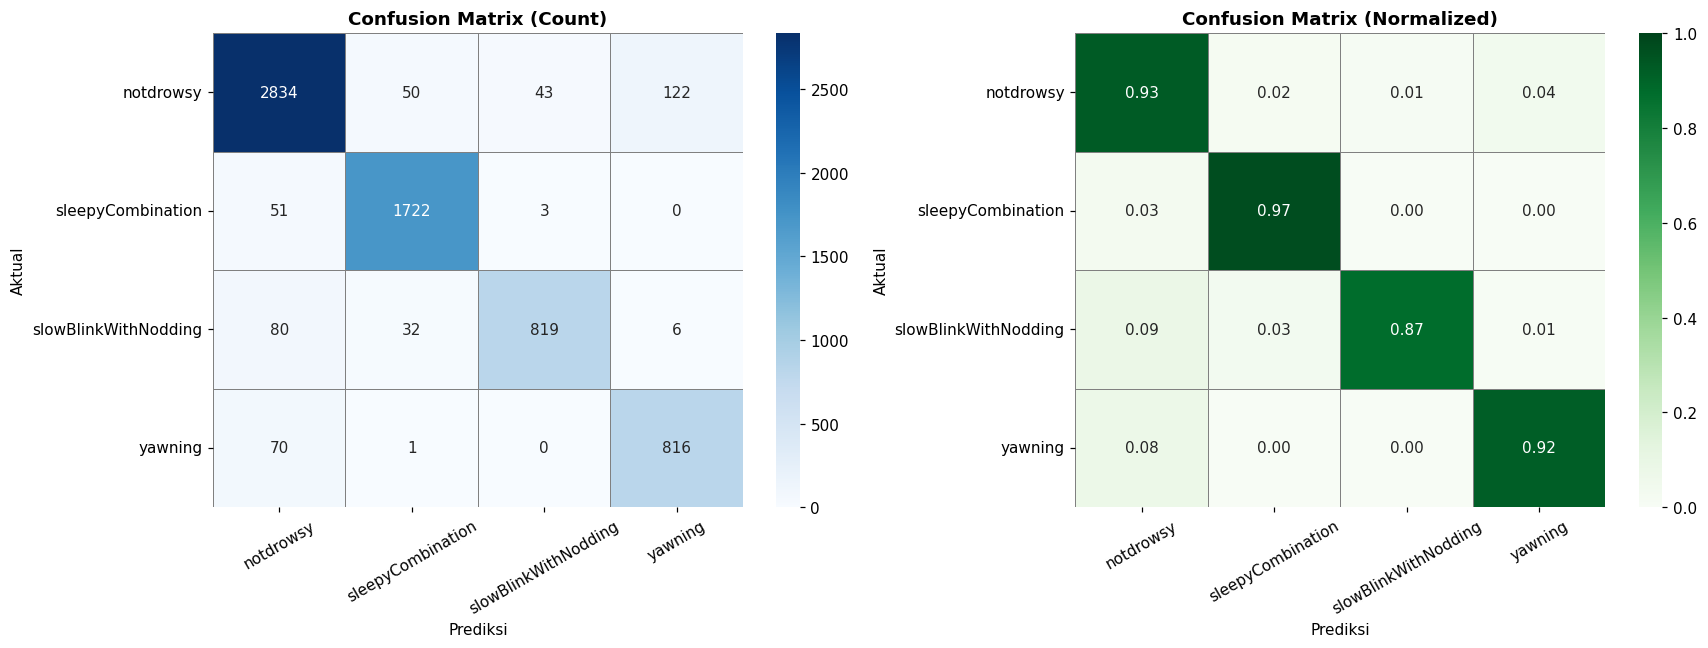


📋 Classification Report:
                      precision    recall  f1-score   support

           notdrowsy       0.93      0.93      0.93      3049
   sleepyCombination       0.95      0.97      0.96      1776
slowBlinkWithNodding       0.95      0.87      0.91       937
             yawning       0.86      0.92      0.89       887

            accuracy                           0.93      6649
           macro avg       0.92      0.92      0.92      6649
        weighted avg       0.93      0.93      0.93      6649



In [ ]:
# 6.3 Confusion Matrix

# Filter hanya kelas 1-4
valid_mask = [(t > 0 and p > 0) for t, p in zip(all_true_labels, all_pred_labels)]
true_filt  = [all_true_labels[i] for i, v in enumerate(valid_mask) if v]
pred_filt  = [all_pred_labels[i] for i, v in enumerate(valid_mask) if v]
class_names = CFG['CLASSES'][1:]
class_idxs  = list(range(1, len(CFG['CLASSES'])))

cm = confusion_matrix(true_filt, pred_filt, labels=class_idxs)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
axes[0].tick_params(axis='x', rotation=30)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, linecolor='gray',
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('./src/confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

# Classification Report
print('\n📋 Classification Report:')
print(classification_report(
    true_filt, pred_filt,
    labels=class_idxs,
    target_names=class_names
))

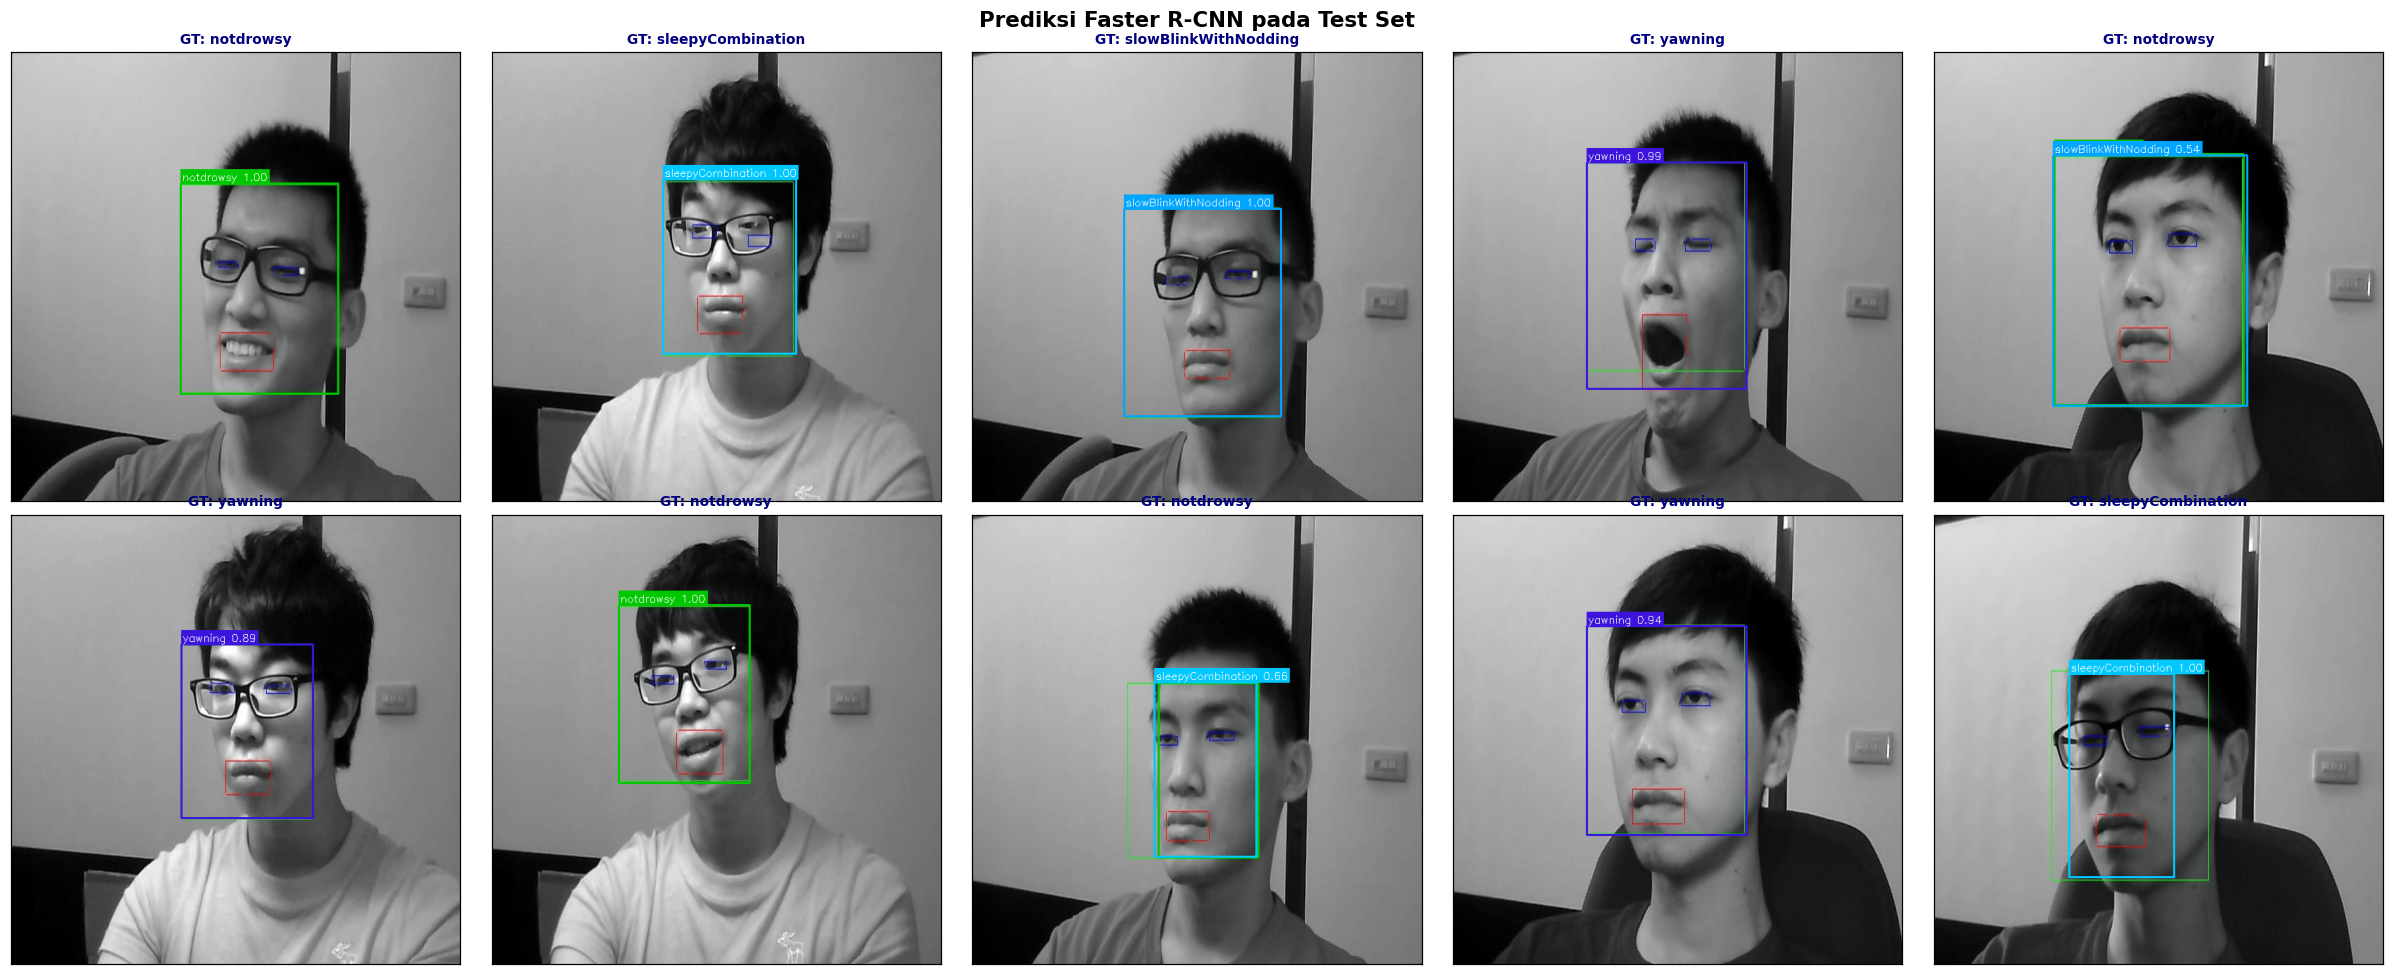

In [ ]:
# 6.4 Visualisasi Prediksi pada Test Set
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.permute(1,2,0).numpy()
    img = img * STD + MEAN
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img

def draw_predictions(img_np, pred, classes, score_thresh=0.3):
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    for box, label, score in zip(pred['boxes'], pred['labels'], pred['scores']):
        if score < score_thresh:
            continue
        x1,y1,x2,y2 = [int(c) for c in box]
        cls_name = classes[label.item()] if label.item() < len(classes) else 'unknown'
        color = CLASS_COLORS.get(cls_name, (200,200,200))
        cv2.rectangle(img_bgr, (x1,y1), (x2,y2), color, 2)
        label_str = f'{cls_name} {score:.2f}'
        (tw, th), _ = cv2.getTextSize(label_str, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img_bgr, (x1, y1-th-8), (x1+tw+4, y1), color, -1)
        cv2.putText(img_bgr, label_str, (x1+2, y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Ambil 10 sampel dari test set
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
model.eval()
sample_iter = iter(test_loader)

with torch.no_grad():
    for i in range(10):
        ax = axes[i//5][i%5]
        try:
            imgs, tgts = next(sample_iter)
            img_tensor = imgs[0]
            preds = model([img_tensor.to(DEVICE)])
            pred_cpu = {k: v.cpu() for k,v in preds[0].items()}

            img_np   = denormalize(img_tensor.cpu())
            img_draw = draw_predictions(img_np, pred_cpu, CFG['CLASSES'])

            ax.imshow(img_draw)
            true_lbl = CFG['CLASSES'][tgts[0]['labels'][0].item()]
            ax.set_title(f'GT: {true_lbl}', fontsize=9, fontweight='bold', color='navy')
        except StopIteration:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Prediksi Faster R-CNN pada Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./src/test_predictions.png', bbox_inches='tight', dpi=120)
plt.show()

## BAGIAN 7: Kuantisasi Model dan Pengujian

### 7.1 Fitur Quantization pada Faster R-CNN
Untuk Faster R-CNN (dengan backbone ResNet), PTDQ (Post-Training Dynamic Quantization) merupakan fitur kompresi yang paling cocok dan simpel diterapkan tanpa harus melakukan kalibrasi dataset ulang. Dynamic Quantization secara cerdas akan mengkuantisasi memori dari operasi `nn.Linear` (terdapat banyak di lapisan RoI Heads model ini) dari `float32` ke `int8`.

In [ ]:
# 7.1 Dynamic Quantization (Linear Layers)
print("⚡ Menerapkan Post-Training Dynamic Quantization (PTDQ)...")
# 1. Muat bobot model terbaik dari drive ke model global
ckpt_best = torch.load(os.path.join(CFG['CHECKPOINT_DIR'], 'best_model.pth'), map_location='cpu')
model.load_state_dict(ckpt_best['model_state_dict'])
model.cpu()
model.eval()

# 2. Menerapkan dynamic quantization pada layer Linear
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)

# 3. Mengecek perubahan ukuran (memory size)
def print_size_of_model(mdl):
    torch.save(mdl.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1e6
    os.remove('temp.p')
    return size

size_original = print_size_of_model(model)
size_quantized = print_size_of_model(quantized_model)

print(f"📦 Ukuran Model Asli       : {size_original:.2f} MB")
print(f"📦 Ukuran Model Quantized  : {size_quantized:.2f} MB")
print(f"📉 Pengurangan Ukuran      : {(size_original - size_quantized) / size_original * 100:.1f} %")

# Kembalikan model asli ke DEVICE
model.to(DEVICE)


⚡ Menerapkan Post-Training Dynamic Quantization (PTDQ)...
📦 Ukuran Model Asli       : 165.77 MB
📦 Ukuran Model Quantized  : 124.01 MB
📉 Pengurangan Ukuran      : 25.2 %


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### 7.2 Evaluasi Quantized Model pada Test Set
Cell berikut akan memvalidasi apakah proses kuantisasi berdampak signifikan terhadap penurunan kemampuan prediksi model. Evaluasi dijalankan menggunakan `test_loader`.

In [ ]:
# 7.2 Evaluasi Quantized Model di Test Set
print("🔎 Mengevaluasi Quantized Model di Test Set (CPU)...")
quantized_model.eval()

metric_q = MeanAveragePrecision(iou_type='bbox', class_metrics=False)

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='Evaluasi Quantized Model'):
        # images di-pass ke dalam format tensor CPU
        images_cpu = [img.cpu() for img in images]
        preds  = quantized_model(images_cpu)

        preds_cpu   = [{k: v.cpu() for k,v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]
        metric_q.update(preds_cpu, targets_cpu)

results_q = metric_q.compute()
print(f"✅ Quantized Model mAP pada Test Set: {results_q['map'].item():.4f}")
